# Synthetic Dataset


Import libraries


In [2]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from custom_lstm.utils import ew_acf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from hurst import compute_Hc

In [3]:
OUTPUT_FILE = "../../data/preprocessed/synthetic_dataset.csv"

In [ ]:
LENGTH = 1000
START = -0.5

rng = np.random.default_rng(seed=42)
time_series_1 = [START]
for i in range(LENGTH - 1):
    time_series_1.append(0.9 * time_series_1[i] + 0.1 * rng.normal())

time_series_2 = [time_series_1[-1]]
for i in range(LENGTH - 1):
    time_series_2.append(-0.9 * time_series_2[i] + 0.1 * rng.normal())

time_series_3 = list(rng.normal(size=LENGTH) * 0.2)

time_series = np.concatenate([time_series_1, time_series_2, time_series_3])

pd.DataFrame(time_series, columns=["time_series"]).to_csv(OUTPUT_FILE, index=False)

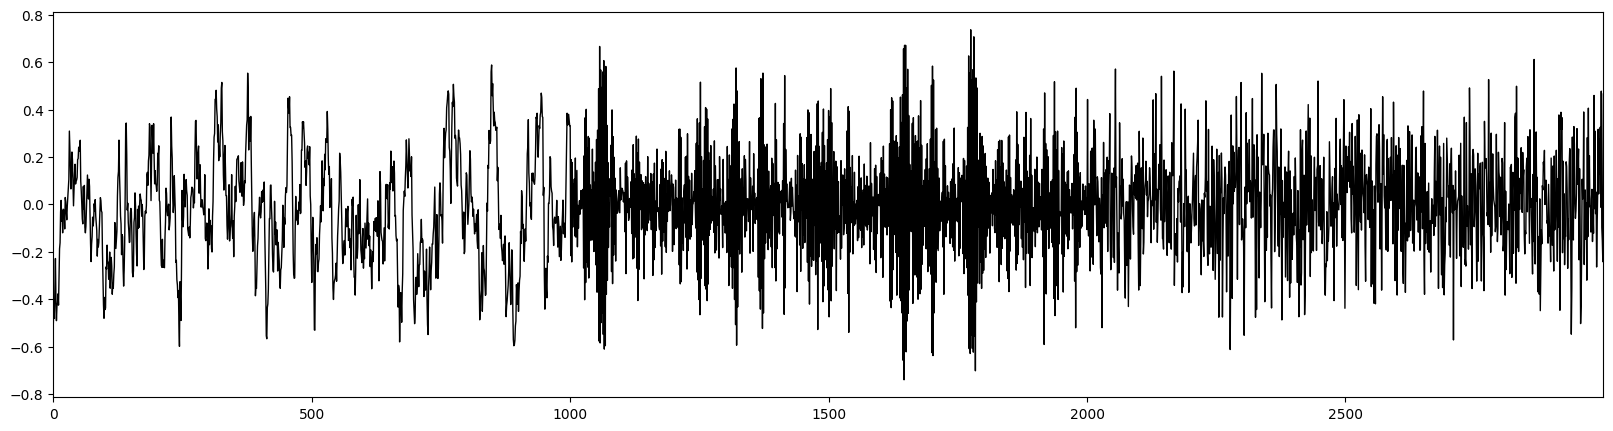

In [15]:
# Plot Complete Time Series

plt.figure(figsize=(20, 5))
plt.margins(x=0)
plt.plot(time_series, color="black", linewidth=1)

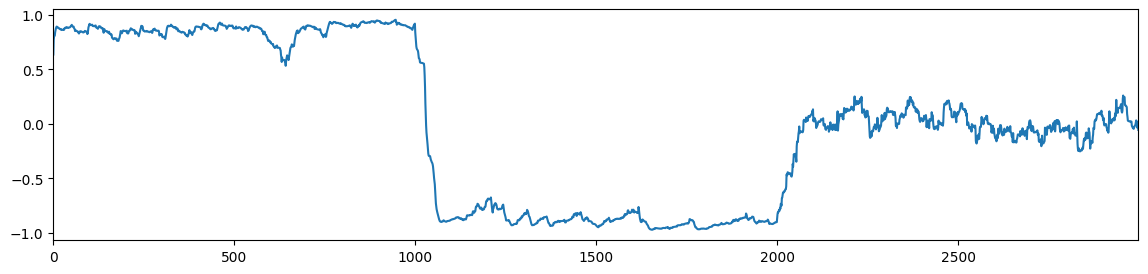

: 

In [ ]:
autocorr = ew_acf(time_series, lag=1, lambda_=0.97)
plt.figure(figsize=(14, 3))
plt.margins(x=0)
plt.plot(autocorr)

### ACF


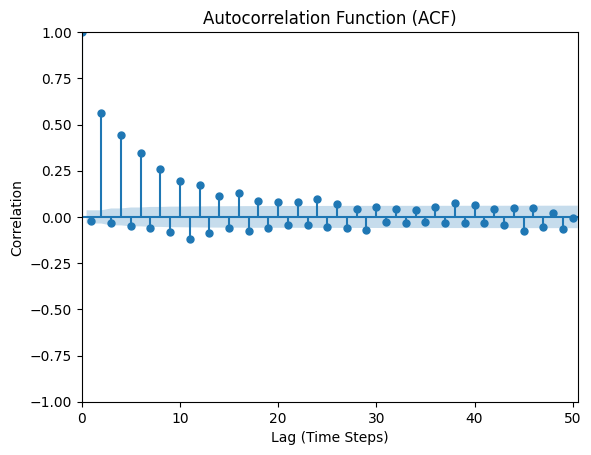

In [ ]:
plot_acf(time_series, lags=50, alpha=0.05)
plt.title("Autocorrelation Function (ACF)")
plt.xlabel("Lag (Time Steps)")
plt.ylabel("Correlation")
plt.show()

### PACF


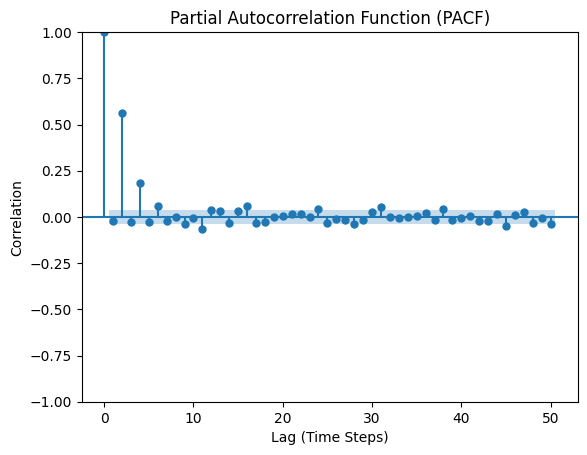

In [8]:
plot_pacf(time_series, lags=50)
plt.title("Partial Autocorrelation Function (PACF)")
plt.xlabel("Lag (Time Steps)")
plt.ylabel("Correlation")
plt.show()

## Hurst Exponent


Hurst Exponent (H): 0.4967


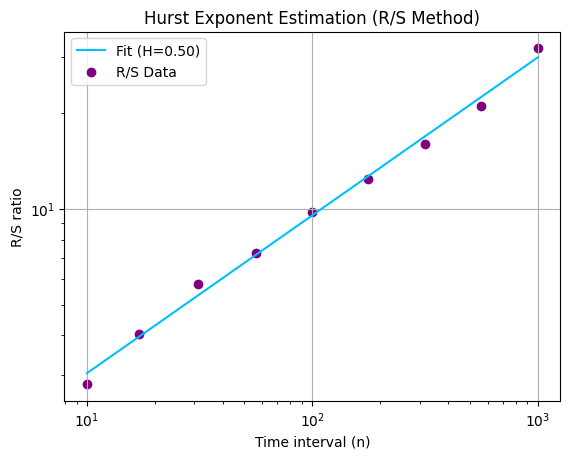

In [9]:
H, c, data = compute_Hc(time_series[2000:3000], kind="change", simplified=False)

print(f"Hurst Exponent (H): {H:.4f}")
f, ax = plt.subplots()
ax.plot(data[0], c * data[0] ** H, color="deepskyblue", label=f"Fit (H={H:.2f})")
ax.scatter(data[0], data[1], color="purple", label="R/S Data")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Time interval (n)")
ax.set_ylabel("R/S ratio")
ax.legend()
plt.title("Hurst Exponent Estimation (R/S Method)")
plt.grid(True)
plt.show()